In [2]:
import os

os.chdir(r"C:\Users\shivy\Desktop\weather-intelligence-platform")

print("Current Directory:", os.getcwd())

Current Directory: C:\Users\shivy\Desktop\weather-intelligence-platform


In [1]:
import os
print(os.getcwd())

c:\Users\shivy\Desktop\weather-intelligence-platform\notebooks


In [5]:
import os

print("Current directory:", os.getcwd())

Current directory: C:\Users\shivy\Desktop\weather-intelligence-platform


In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current working directory:
c:\Users\shivy\Desktop\weather-intelligence-platform\notebooks\.gitkeep

Files here:
['01_EDA.ipynb']


In [1]:
import os

print("Current Directory:", os.getcwd())

print("\nContents:")
print(os.listdir())

Current Directory: c:\Users\shivy\Desktop\weather-intelligence-platform\notebooks\.gitkeep

Contents:
['01_EDA.ipynb']


In [6]:
# Cell 1: Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the combined dataset
df = pd.read_csv(
    r"C:\Users\shivy\Desktop\weather-intelligence-platform\data\raw\india_weather_1990_2024.csv",
    parse_dates=["date"]
)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Cities: {df['city'].unique()}")
print(f"\nTotal records: {len(df):,}")

Dataset loaded successfully!
Shape: (76704, 22)

Columns: ['date', 'city', 'latitude', 'longitude', 'precipitation_mm', 'temp_max_c', 'temp_min_c', 'temp_mean_c', 'humidity_max_pct', 'humidity_min_pct', 'wind_speed_max_kmh', 'wind_direction_deg', 'cloud_cover_pct', 'evapotranspiration_mm', 'weather_code', 'year', 'month', 'day', 'day_of_year', 'week_of_year', 'is_monsoon_season', 'state']

Date range: 1990-01-01 to 2024-12-31
Cities: ['Bengaluru' 'Chennai' 'Delhi' 'Jaipur' 'Kolkata' 'Mumbai']

Total records: 76,704


In [12]:
from pathlib import Path
import os

# Change this if your project is stored somewhere else
PROJECT_ROOT = Path(r"C:\Users\shivy\Desktop\weather-intelligence-platform")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"

# Automatically create folders if they don't exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Raw Data:", DATA_RAW)
print("Processed Data:", DATA_PROCESSED)
print("Figures:", FIGURES)

Project Root: C:\Users\shivy\Desktop\weather-intelligence-platform
Raw Data: C:\Users\shivy\Desktop\weather-intelligence-platform\data\raw
Processed Data: C:\Users\shivy\Desktop\weather-intelligence-platform\data\processed
Figures: C:\Users\shivy\Desktop\weather-intelligence-platform\reports\figures


In [7]:
# Cell 2: Basic Statistics
print("=" * 60)
print("BASIC DATASET STATISTICS")
print("=" * 60)

print("\n1. Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n2. Descriptive Statistics:")
numeric_cols = ['precipitation_mm', 'temp_max_c', 'temp_min_c', 
                'humidity_max_pct', 'wind_speed_max_kmh',
                'cloud_cover_pct']
print(df[numeric_cols].describe().round(2))

print("\n3. Records per City:")
print(df['city'].value_counts())

print("\n4. Data Types:")
print(df.dtypes)

BASIC DATASET STATISTICS

1. Missing Values per Column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

2. Descriptive Statistics:
       precipitation_mm  temp_max_c  temp_min_c  humidity_max_pct  \
count          76704.00    76704.00    76704.00          76704.00   
mean               3.13       30.45       21.24             85.42   
std                8.87        4.69        5.56             15.20   
min                0.00       12.35        2.00              9.22   
25%                0.00       27.45       18.20             81.16   
50%                0.00       30.50       22.36             91.40   
75%                2.10       33.25       25.56             95.35   
max              255.80       46.85       35.25            100.00   

       wind_speed_max_kmh  cloud_cover_pct  
count            76704.00         76704.00  
mean                15.87            47.11  
std                  5.15            36.21  
min                  4.21             0.00  
25%    

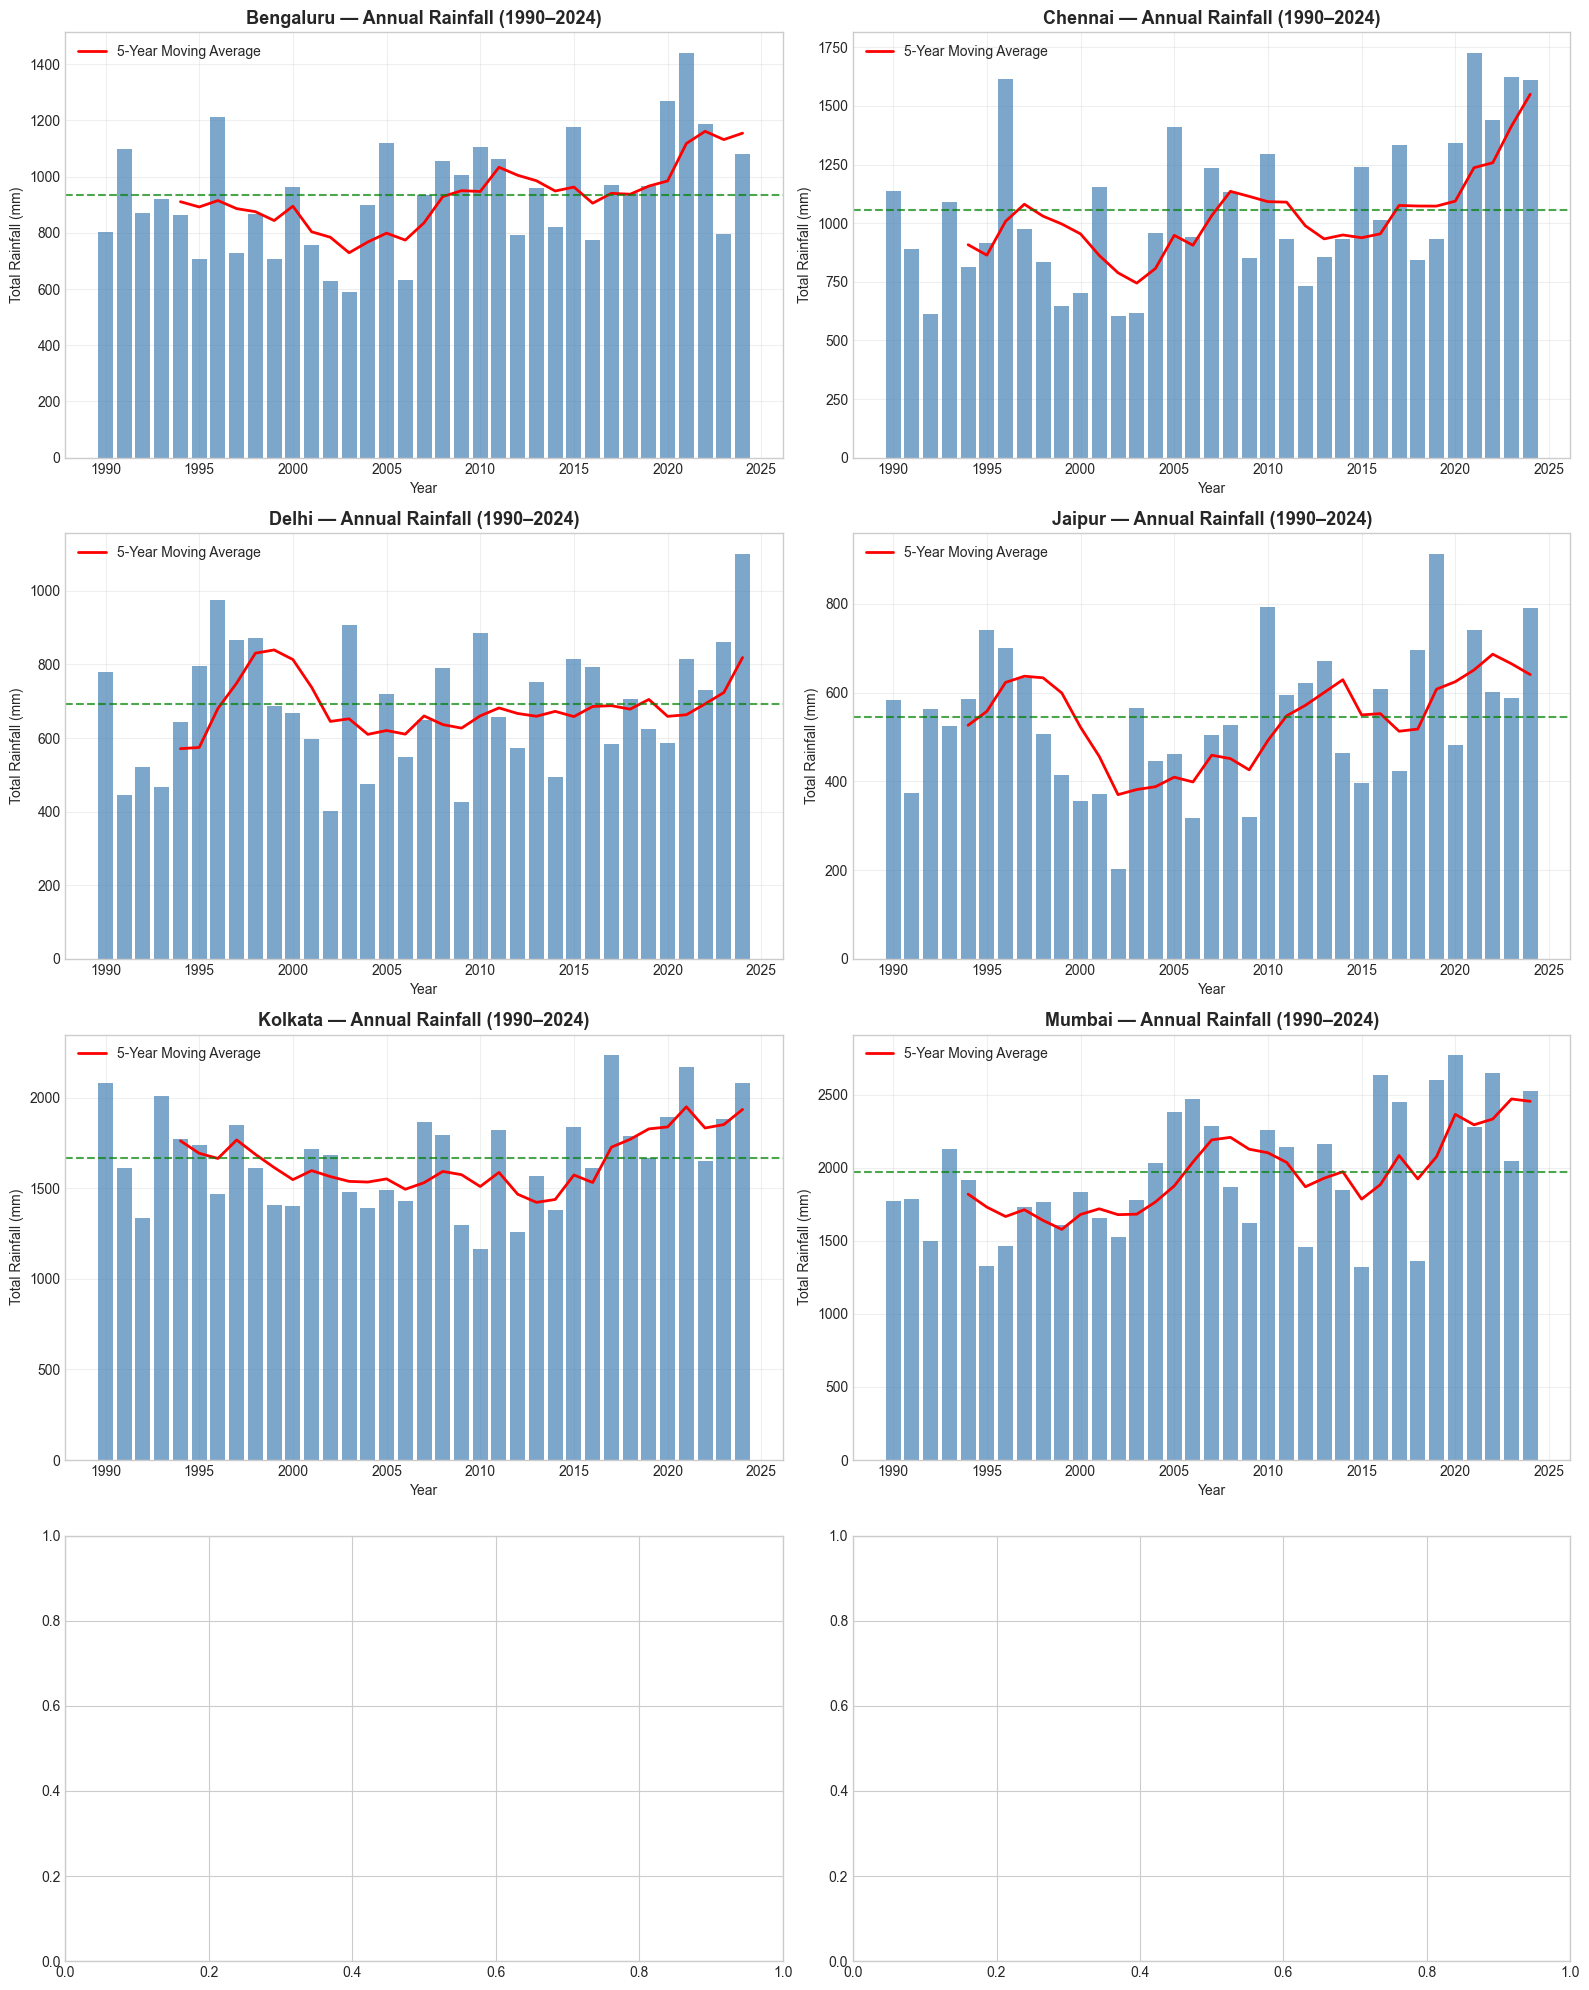

✅ Plot saved successfully!
Plot saved!


In [13]:
# Cell 3: Annual Rainfall by City
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

cities = df['city'].unique()

for idx, city in enumerate(cities):
    city_data = df[df['city'] == city].copy()
    annual = city_data.groupby('year')['precipitation_mm'].sum().reset_index()
    
    ax = axes[idx]
    ax.bar(annual['year'], annual['precipitation_mm'], 
           color='steelblue', alpha=0.7, width=0.8)
    ax.plot(annual['year'], annual['precipitation_mm'].rolling(5).mean(), 
            color='red', linewidth=2, label='5-Year Moving Average')
    
    ax.set_title(f'{city} — Annual Rainfall (1990–2024)', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Rainfall (mm)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add mean line
    mean_rain = annual['precipitation_mm'].mean()
    ax.axhline(y=mean_rain, color='green', linestyle='--', 
               alpha=0.7, label=f'Mean: {mean_rain:.0f}mm')

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    FIGURES / "annual_rainfall_all_cities.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Plot saved successfully!")
plt.show()
print("Plot saved!")

In [14]:
# Cell 4: Monthly Rainfall Pattern (Monsoon Analysis)
monthly_avg = df.groupby(['city', 'month'])['precipitation_mm'].mean().reset_index()

fig = px.bar(
    monthly_avg,
    x='month',
    y='precipitation_mm',
    color='city',
    barmode='group',
    title='Average Monthly Rainfall by City — Monsoon Pattern (1990–2024)',
    labels={
        'precipitation_mm': 'Average Daily Rainfall (mm)',
        'month': 'Month',
        'city': 'City'
    },
    height=500
)

# Add month names
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
fig.update_xaxes(ticktext=month_names, tickvals=list(range(1,13)))

# Add shading for monsoon season
fig.add_vrect(x0=5.5, x1=9.5,
              fillcolor="lightblue", opacity=0.2,
              annotation_text="SW Monsoon Season",
              annotation_position="top left")

fig.show()
fig.write_html(FIGURES / "monthly_rainfall_pattern.html")
print("Interactive plot saved!")

Interactive plot saved!


Temperature plot saved!


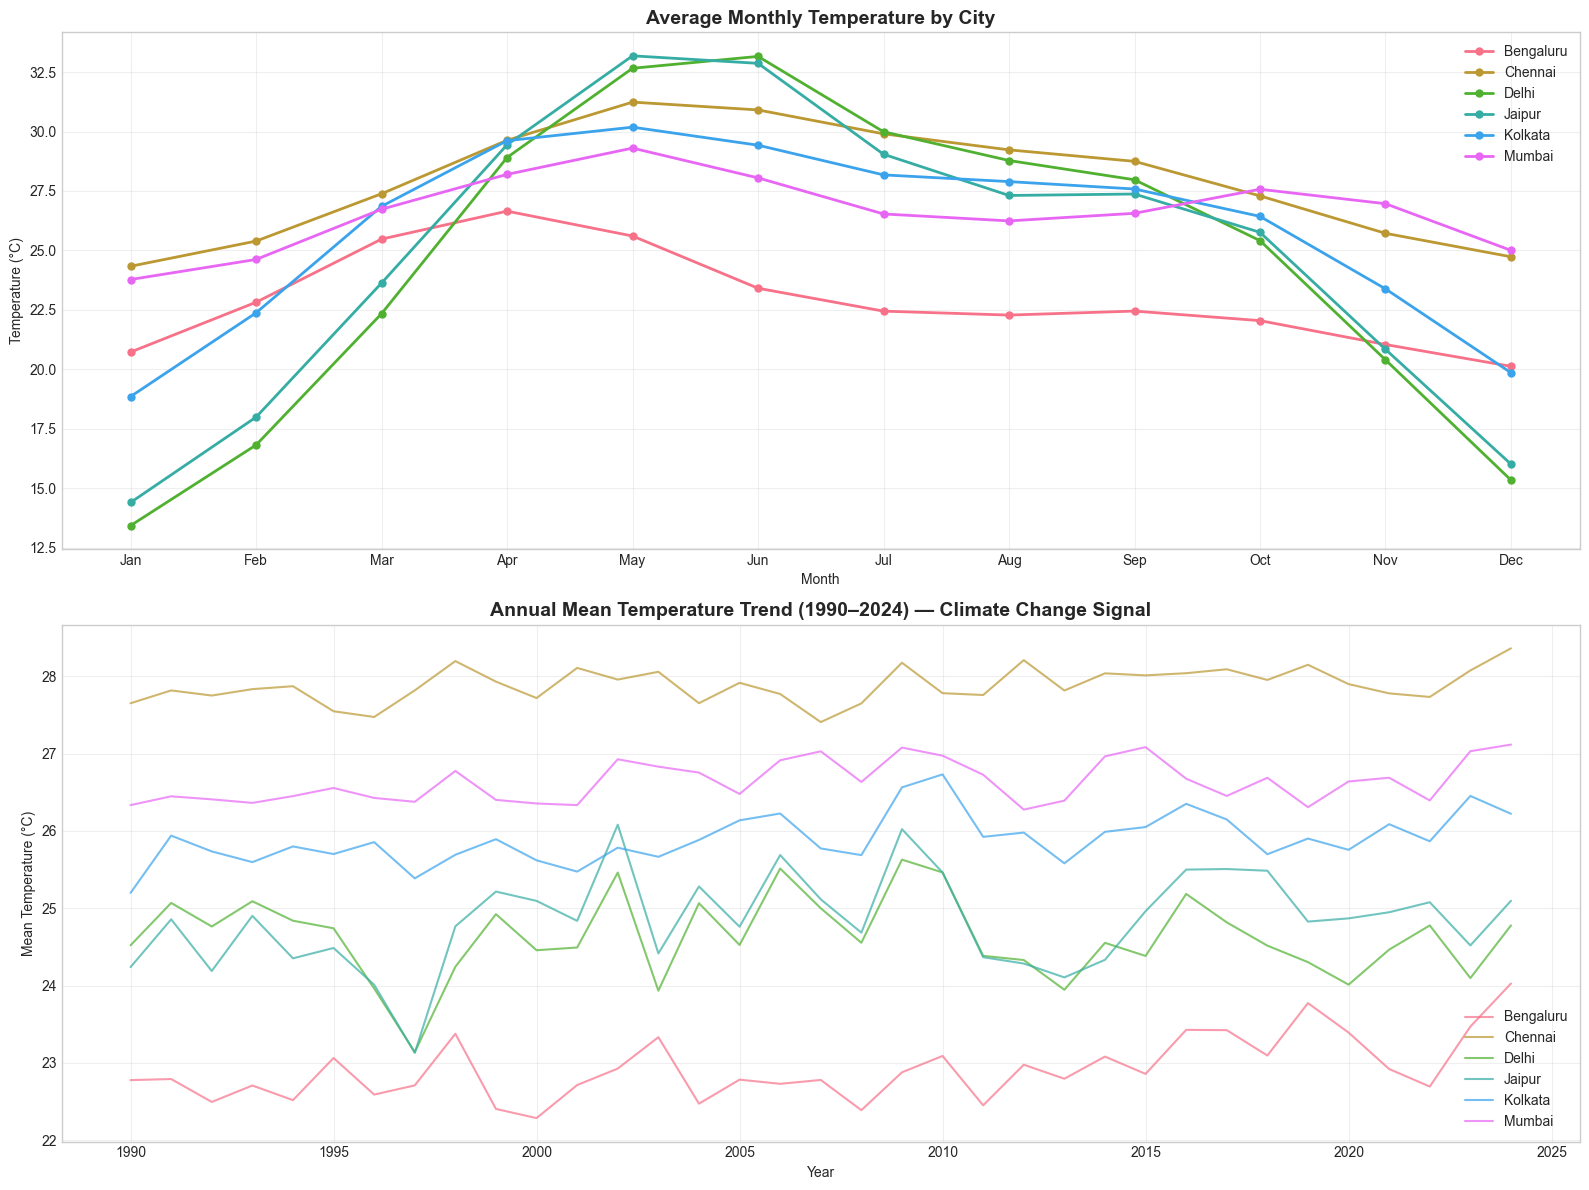

In [15]:
# Cell 5: Temperature Analysis
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Monthly average temperature for all cities
monthly_temp = df.groupby(['city', 'month']).agg({
    'temp_max_c': 'mean',
    'temp_min_c': 'mean',
    'temp_mean_c': 'mean'
}).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for city in cities:
    city_data = monthly_temp[monthly_temp['city'] == city]
    axes[0].plot(city_data['month'], city_data['temp_mean_c'], 
                 marker='o', linewidth=2, markersize=5, label=city)

axes[0].set_title('Average Monthly Temperature by City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Annual temperature trend (climate change signal)
annual_temp = df.groupby(['city', 'year'])['temp_mean_c'].mean().reset_index()

for city in cities:
    city_data = annual_temp[annual_temp['city'] == city]
    axes[1].plot(city_data['year'], city_data['temp_mean_c'], 
                 linewidth=1.5, alpha=0.7, label=city)

axes[1].set_title('Annual Mean Temperature Trend (1990–2024) — Climate Change Signal', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES / "temperature_analysis.png",
    dpi=150,
    bbox_inches="tight"
)

print("Temperature plot saved!")
plt.show()

Heatmap saved!


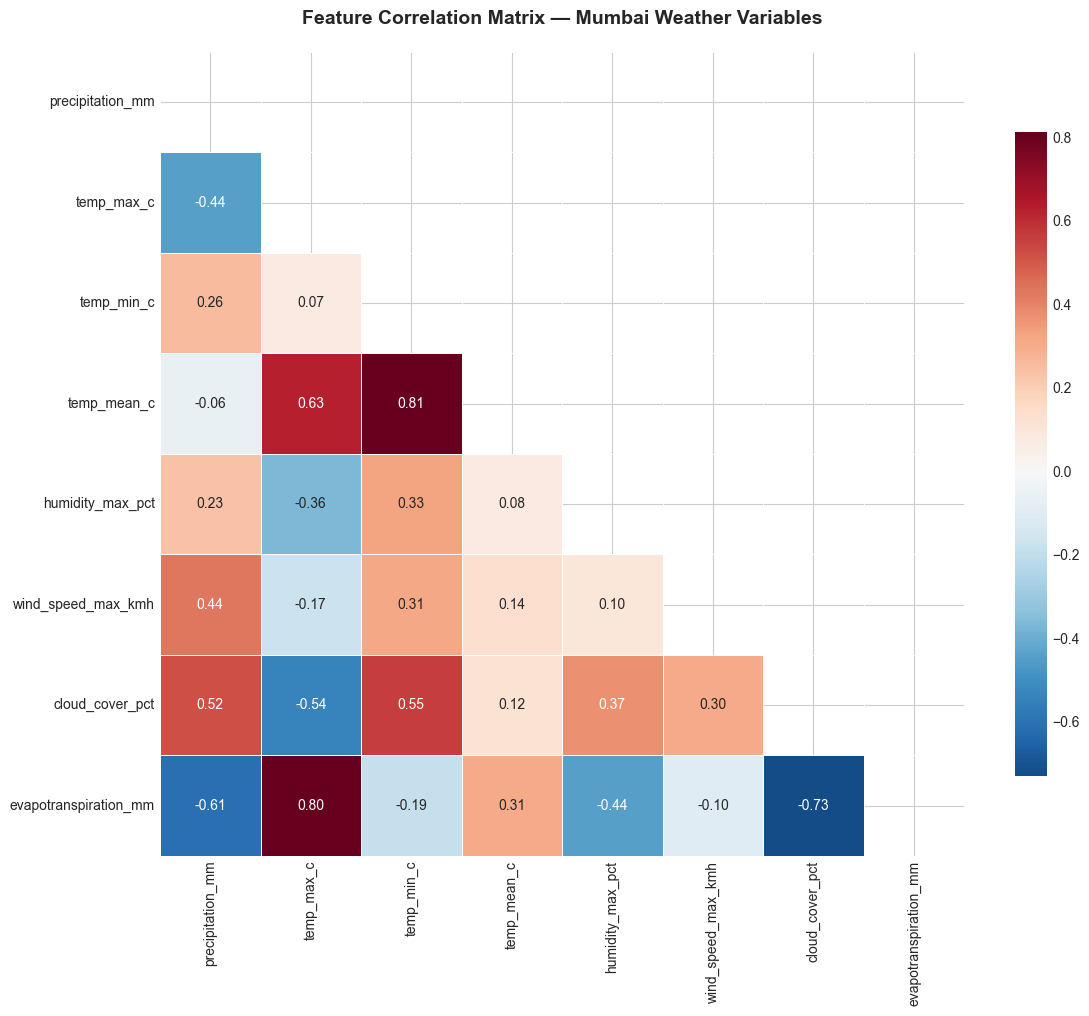


Key Correlations with Rainfall:
precipitation_mm         1.000000
cloud_cover_pct          0.518776
wind_speed_max_kmh       0.436935
temp_min_c               0.257960
humidity_max_pct         0.234215
temp_mean_c             -0.055327
temp_max_c              -0.443969
evapotranspiration_mm   -0.608049
Name: precipitation_mm, dtype: float64


In [20]:
# Cell 6: Correlation Analysis
# Focus on Mumbai as example (most monsoon-relevant city)
mumbai = df[df['city'] == 'Mumbai'].copy()

# Calculate correlations
corr_vars = ['precipitation_mm', 'temp_max_c', 'temp_min_c', 'temp_mean_c',
             'humidity_max_pct', 'wind_speed_max_kmh',
             'cloud_cover_pct', 'evapotranspiration_mm']

corr_matrix = mumbai[corr_vars].corr()

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title('Feature Correlation Matrix — Mumbai Weather Variables', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(
    FIGURES / "correlation_heatmap_mumbai.png",
    dpi=150,
    bbox_inches="tight"
)

print("Heatmap saved!")
plt.show()

print("\nKey Correlations with Rainfall:")
print(corr_matrix['precipitation_mm'].sort_values(ascending=False))

MONSOON SEASON ANALYSIS (June-September)

Average Monsoon Season Rainfall by City (1990-2024):
          total_monsoon_rainfall_mm                        monsoon_rain_days  \
                               mean    std     min     max              mean   
city                                                                           
Bengaluru                     508.2  135.5   295.9   917.3              74.6   
Chennai                       359.8  148.7   102.1   764.4              56.1   
Delhi                         553.5  159.0   288.6   990.2              58.1   
Jaipur                        476.5  149.2   162.4   839.0              53.0   
Kolkata                      1213.1  208.1   877.1  1625.0             104.7   
Mumbai                       1852.0  403.5  1235.2  2628.7             110.8   

          max_daily_rain_mm  
                       mean  
city                         
Bengaluru              32.4  
Chennai                33.6  
Delhi                  63.5  
Jaip

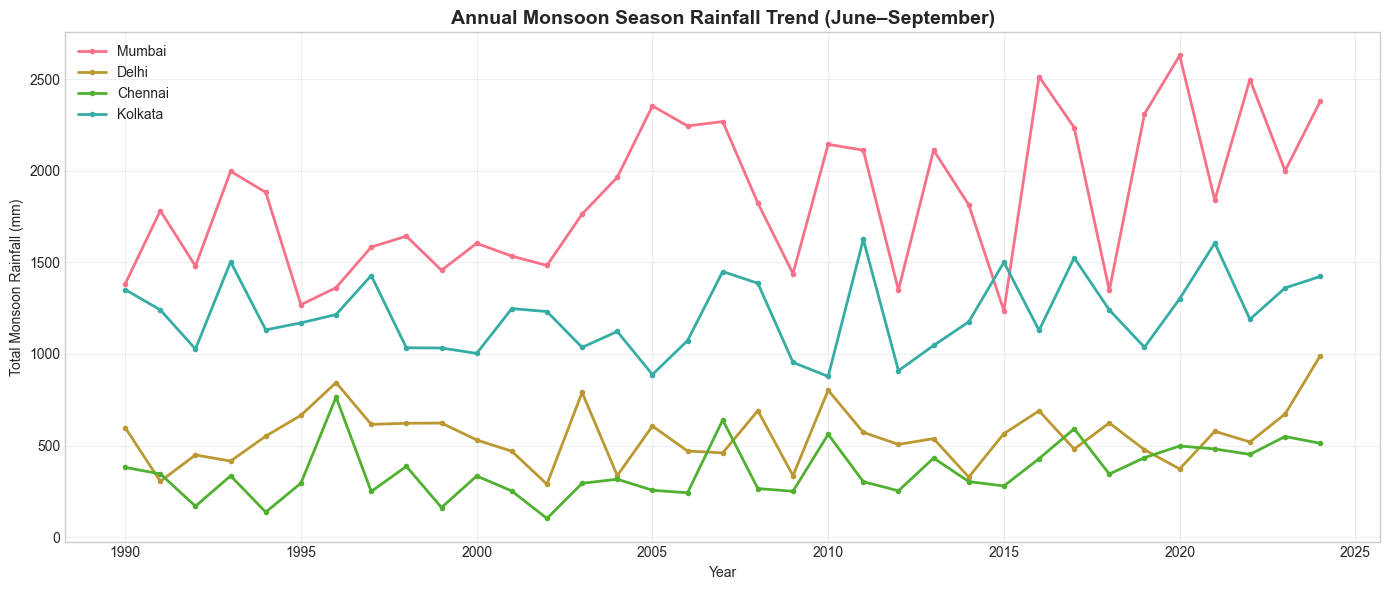

In [21]:
# Cell 7: Monsoon Onset and Duration Analysis
print("MONSOON SEASON ANALYSIS (June-September)")
print("=" * 60)

monsoon_analysis = []

for city in cities:
    city_data = df[df['city'] == city].copy()
    
    for year in city_data['year'].unique():
        year_data = city_data[city_data['year'] == year]
        monsoon_data = year_data[year_data['month'].isin([6,7,8,9])]
        
        monsoon_analysis.append({
            'city': city,
            'year': year,
            'total_monsoon_rainfall_mm': monsoon_data['precipitation_mm'].sum(),
            'monsoon_rain_days': (monsoon_data['precipitation_mm'] > 1).sum(),
            'max_daily_rain_mm': monsoon_data['precipitation_mm'].max(),
            'avg_monsoon_humidity': monsoon_data['humidity_max_pct'].mean(),
        })

monsoon_df = pd.DataFrame(monsoon_analysis)

# Summary statistics
print("\nAverage Monsoon Season Rainfall by City (1990-2024):")
summary = monsoon_df.groupby('city').agg({
    'total_monsoon_rainfall_mm': ['mean', 'std', 'min', 'max'],
    'monsoon_rain_days': 'mean',
    'max_daily_rain_mm': 'mean'
}).round(1)
print(summary)

# Save monsoon analysis
monsoon_df.to_csv(
    DATA_PROCESSED / "monsoon_analysis.csv",
    index=False
)
print("\nMonsoon analysis saved!")

# Plot monsoon rainfall trends
fig, ax = plt.subplots(figsize=(14, 6))
for city in ['Mumbai', 'Delhi', 'Chennai', 'Kolkata']:
    city_data = monsoon_df[monsoon_df['city'] == city]
    ax.plot(city_data['year'], city_data['total_monsoon_rainfall_mm'],
            linewidth=2, label=city, marker='o', markersize=3)

ax.set_title('Annual Monsoon Season Rainfall Trend (June–September)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Monsoon Rainfall (mm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES / "monsoon_trend.png",
    dpi=150,
    bbox_inches="tight"
)

print("Monsoon analysis saved!")
plt.show()

EXTREME RAINFALL EVENTS

Total extreme rainfall events (≥115.5mm/day): 48

Top 15 Extreme Rainfall Events:
      date    city  precipitation_mm    rainfall_category
2023-12-04 Chennai         255.80000 Extremely Heavy Rain
2016-09-22  Mumbai         251.10002 Extremely Heavy Rain
2011-06-10  Mumbai         234.59999 Extremely Heavy Rain
1996-06-14 Chennai         231.80000 Extremely Heavy Rain
1999-07-28   Delhi         228.50000 Extremely Heavy Rain
1993-07-03  Mumbai         220.40000 Extremely Heavy Rain
2021-05-17  Mumbai         199.90001      Very Heavy Rain
2019-07-24  Mumbai         197.69998      Very Heavy Rain
2021-11-11 Chennai         186.30000      Very Heavy Rain
2010-06-14  Mumbai         175.99998      Very Heavy Rain
2020-07-04  Mumbai         169.79999      Very Heavy Rain
1990-10-09  Mumbai         159.50000      Very Heavy Rain
2024-11-30 Chennai         158.40001      Very Heavy Rain
1994-08-31  Mumbai         157.09999      Very Heavy Rain
2011-06-17 Kolkata     

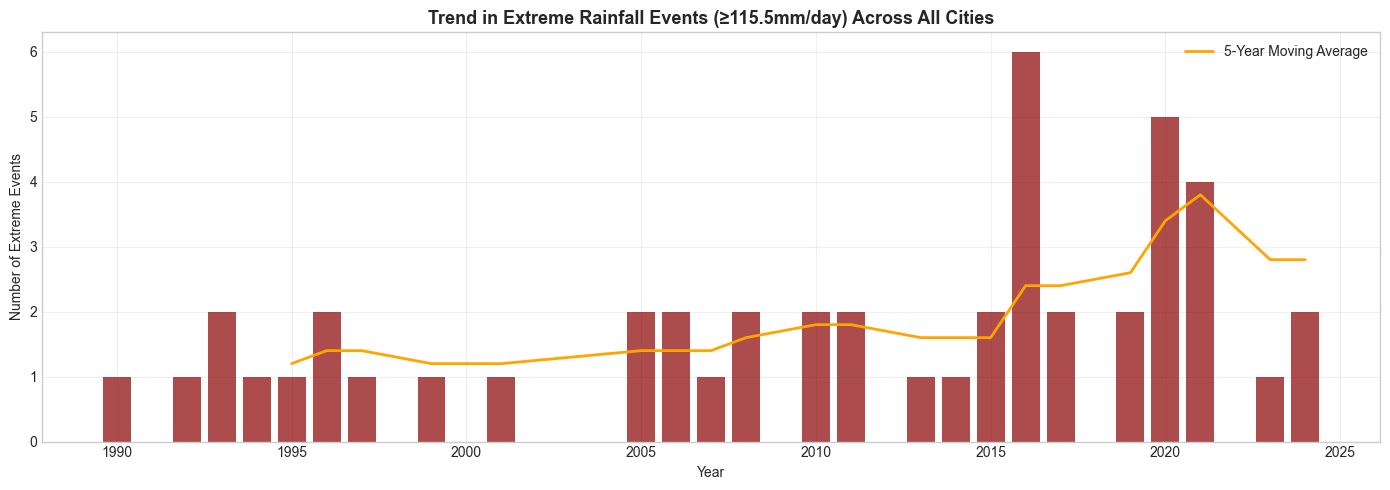

In [22]:
# Cell 8: Extreme Rainfall Events Analysis
print("EXTREME RAINFALL EVENTS")
print("=" * 60)

# Define thresholds for extreme rainfall (IMD classification)
# Heavy Rain: 64.5 - 115.5 mm/day
# Very Heavy Rain: 115.6 - 204.4 mm/day  
# Extremely Heavy Rain: > 204.4 mm/day

def classify_rainfall(mm):
    if mm < 2.5:
        return "No/Trace Rain"
    elif mm < 7.5:
        return "Light Rain"
    elif mm < 35.5:
        return "Moderate Rain"
    elif mm < 64.5:
        return "Rather Heavy Rain"
    elif mm < 115.5:
        return "Heavy Rain"
    elif mm < 204.4:
        return "Very Heavy Rain"
    else:
        return "Extremely Heavy Rain"

df['rainfall_category'] = df['precipitation_mm'].apply(classify_rainfall)

# Extreme events (Very Heavy + Extremely Heavy)
extreme = df[df['precipitation_mm'] >= 115.5].copy()
extreme = extreme.sort_values('precipitation_mm', ascending=False)

print(f"\nTotal extreme rainfall events (≥115.5mm/day): {len(extreme)}")
print(f"\nTop 15 Extreme Rainfall Events:")
print(extreme[['date','city','precipitation_mm','rainfall_category']].head(15).to_string(index=False))

print(f"\nExtreme Events by City:")
print(extreme['city'].value_counts())

print(f"\nExtreme Events by Month:")
print(extreme['month'].value_counts().sort_index())

# Trend in extreme events over time
extreme_by_year = extreme.groupby('year').size().reset_index(name='extreme_event_count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(extreme_by_year['year'], extreme_by_year['extreme_event_count'],
       color='darkred', alpha=0.7)
ax.plot(extreme_by_year['year'], 
        extreme_by_year['extreme_event_count'].rolling(5).mean(),
        color='orange', linewidth=2, label='5-Year Moving Average')
ax.set_title('Trend in Extreme Rainfall Events (≥115.5mm/day) Across All Cities', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Extreme Events')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES / "extreme_events_trend.png",
    dpi=150,
    bbox_inches="tight"
)

print("Extreme events plot saved!")
plt.show()

In [ ]:
# Cell 9: Geographic Visualization with Folium
import folium
from folium import plugins

# Calculate average annual rainfall for each city
city_stats = df.groupby(['city','latitude','longitude']).agg({
    'precipitation_mm': 'mean',
    'temp_mean_c': 'mean',
    'humidity_max_pct': 'mean'
}).reset_index()

city_stats.columns = ['city','lat','lon','avg_daily_rain_mm','avg_temp_c','avg_humidity']
city_stats['avg_annual_rain_mm'] = city_stats['avg_daily_rain_mm'] * 365

# Create a map centered on India
india_map = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles='CartoDB positron'
)

# Add city markers
for _, row in city_stats.iterrows():
    # Scale circle size by rainfall amount
    radius = row['avg_annual_rain_mm'] / 50
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(radius, 5),
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=folium.Popup(
            f"""
            <b>{row['city']}</b><br>
            Annual Rainfall: {row['avg_annual_rain_mm']:.0f} mm<br>
            Avg Temperature: {row['avg_temp_c']:.1f}°C<br>
            Avg Humidity: {row['avg_humidity']:.0f}%
            """,
            max_width=200
        ),
        tooltip=f"{row['city']}: {row['avg_annual_rain_mm']:.0f} mm/year"
    ).add_to(india_map)

# Save map
india_map.save(FIGURES / "india_rainfall_map.html")

print("Interactive map saved!")
print("Interactive map saved! Open reports/figures/india_rainfall_map.html in browser.")
india_map